
# EMNIST Digits Classification — CNN CPU/GPU Benchmark
## Full dataset, switchable device

This notebook benchmarks **CNN only**.

Change only:

```python
DEVICE = "cpu"
```

or:

```python
DEVICE = "cuda"
```

It uses the **full official EMNIST Digits training split and full official test split with no sampling or subsampling**.

CPU and GPU runs keep the same dataset, preprocessing, architecture, initial weights, batch order, epochs, batch size, optimizer, learning rate, loss, and evaluation.


## 1. Install CodeCarbon

In [1]:

import subprocess
import sys
import importlib.util

def ensure_package(module_name, package_name=None):
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name or module_name,
        ])

ensure_package("codecarbon")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 86.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 50.0.0 which is incompatible.


## 2. Imports

In [2]:

import os
import gc
import copy
import math
import time
import random
import platform
import threading
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    log_loss,
    confusion_matrix,
)

from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CPU cores:", os.cpu_count())
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)


Python: 3.12.13
PyTorch: 2.10.0+cpu
CPU cores: 4
CUDA available: False


## 3. Choose CPU or GPU

In [3]:

# ============================================================
# CHANGE ONLY THIS LINE BETWEEN CPU AND GPU RUNS
# ============================================================
DEVICE = "cpu"          # "cpu" or "cuda"
# ============================================================

DEVICE = DEVICE.lower().strip()

if DEVICE not in {"cpu", "cuda"}:
    raise ValueError('DEVICE must be "cpu" or "cuda".')

if DEVICE == "cuda" and not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA selected but no GPU is available. "
        "On Kaggle, enable Accelerator = GPU."
    )

print("Selected device:", DEVICE.upper())


Selected device: CPU


## 4. Fixed experiment configuration

In [4]:

SEED = 42

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3

NUM_CLASSES = 10

CARBON_MEASURE_SECS = 1

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

set_seed(SEED)

print({
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "classes": NUM_CLASSES,
})


{'device': 'cpu', 'batch_size': 128, 'epochs': 10, 'learning_rate': 0.001, 'classes': 10}



## 5. Load the full EMNIST Digits dataset

No subset indices are created.

The notebook uses:

- `train=True` → complete EMNIST Digits training split
- `train=False` → complete EMNIST Digits test split

`shuffle=True` changes only batch order during training; it does **not** remove or sample observations.


In [5]:

transform = transforms.ToTensor()

train_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform,
)

print("Full training examples:", f"{len(train_dataset):,}")
print("Full test examples:", f"{len(test_dataset):,}")
print(
    "Total EMNIST Digit examples used:",
    f"{len(train_dataset) + len(test_dataset):,}",
)

assert len(train_dataset) > 0
assert len(test_dataset) > 0


100%|██████████| 562M/562M [00:01<00:00, 282MB/s]


Full training examples: 240,000
Full test examples: 40,000
Total EMNIST Digit examples used: 280,000


## 6. Fixed DataLoaders

In [6]:

def make_loaders(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        drop_last=False,
        num_workers=0,
        pin_memory=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=False,
    )

    return train_loader, test_loader

train_loader, test_loader = make_loaders(SEED)

print("Training batches/epoch:", len(train_loader))
print("Test batches:", len(test_loader))


Training batches/epoch: 1875
Test batches: 313


## 7. Preview

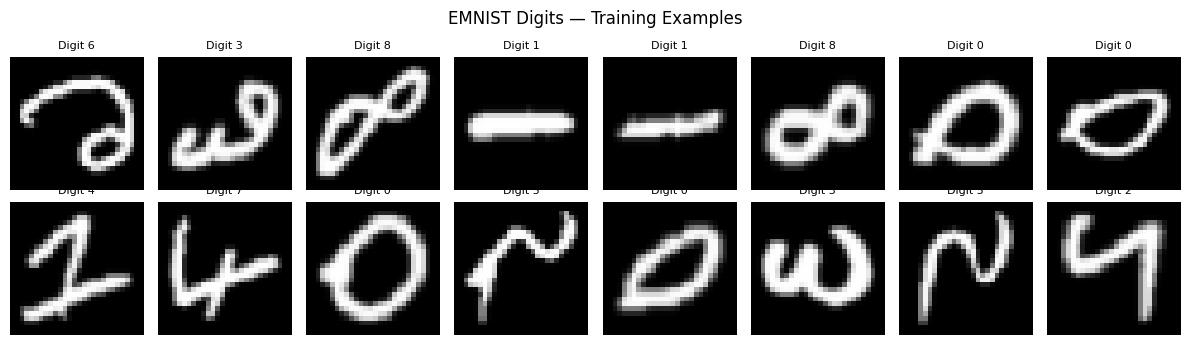

In [7]:

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    2,
    8,
    figsize=(12, 3.5),
)

for ax, image, label in zip(
    axes.ravel(),
    images[:16],
    labels[:16],
):
    ax.imshow(
        image.squeeze(0),
        cmap="gray",
    )

    ax.set_title(
        f"Digit {int(label)}",
        fontsize=8,
    )

    ax.axis("off")

fig.suptitle("EMNIST Digits — Training Examples")
fig.tight_layout()
plt.show()


## 8. CNN model

In [8]:

class EMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64 * 7 * 7,
                128,
            ),
            nn.ReLU(),
            nn.Linear(
                128,
                NUM_CLASSES,
            ),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# Initialize on CPU first so CPU/GPU runs start from identical parameters.
set_seed(SEED)

model = EMNISTCNN()

INITIAL_STATE = copy.deepcopy(
    model.state_dict()
)

model = model.to(DEVICE)

parameter_count = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", f"{parameter_count:,}")
print("Model device:", next(model.parameters()).device)


Trainable parameters: 421,642
Model device: cpu


## 9. Verify deterministic initialization

In [9]:

set_seed(SEED)

reference_model = EMNISTCNN()
reference_state = reference_model.state_dict()

for name, value in INITIAL_STATE.items():
    assert torch.equal(
        value,
        reference_state[name],
    )

del reference_model

print("Initialization verified.")


Initialization verified.


## 10. CodeCarbon and memory helpers

In [10]:

process = psutil.Process(os.getpid())

def sync():
    if DEVICE == "cuda":
        torch.cuda.synchronize()


class PeakMemory:
    def __init__(self, interval=0.10):
        self.interval = interval
        self.peak_rss = 0
        self.stop_event = threading.Event()
        self.thread = None

    def _watch(self):
        while not self.stop_event.is_set():
            try:
                self.peak_rss = max(
                    self.peak_rss,
                    process.memory_info().rss,
                )
            except Exception:
                pass

            time.sleep(self.interval)

    def start(self):
        self.peak_rss = process.memory_info().rss
        self.stop_event.clear()

        self.thread = threading.Thread(
            target=self._watch,
            daemon=True,
        )

        self.thread.start()

    def stop(self):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join(timeout=2)

        return self.peak_rss / (1024 ** 2)


class EnergyTracker:
    def __init__(self, project_name):
        self.tracker = None

        try:
            kwargs = dict(
                project_name=project_name,
                measure_power_secs=CARBON_MEASURE_SECS,
                tracking_mode="process",
                gpu_ids=[0] if DEVICE == "cuda" else [],
                log_level="error",
            )

            try:
                self.tracker = EmissionsTracker(
                    output_methods=[],
                    **kwargs,
                )
            except TypeError:
                self.tracker = EmissionsTracker(
                    save_to_file=False,
                    save_to_api=False,
                    **kwargs,
                )

        except Exception as exc:
            print(
                "CodeCarbon initialization unavailable:",
                exc,
            )

    def start(self):
        if self.tracker is not None:
            try:
                self.tracker.start()
            except Exception as exc:
                print("CodeCarbon start failed:", exc)
                self.tracker = None

    def stop(self):
        if self.tracker is None:
            return self.empty()

        try:
            self.tracker.stop()

            data = getattr(
                self.tracker,
                "final_emissions_data",
                None,
            )

            if data is None:
                return self.empty()

            def attr(name):
                value = getattr(
                    data,
                    name,
                    np.nan,
                )
                return (
                    np.nan
                    if value is None
                    else value
                )

            return {
                "energy_kwh": attr("energy_consumed"),
                "co2_kg": attr("emissions"),
                "cpu_energy_kwh": attr("cpu_energy"),
                "gpu_energy_kwh": attr("gpu_energy"),
                "ram_energy_kwh": attr("ram_energy"),
                "cpu_power_w": attr("cpu_power"),
                "gpu_power_w": attr("gpu_power"),
                "country": getattr(
                    data,
                    "country_name",
                    None,
                ),
            }

        except Exception as exc:
            print("CodeCarbon stop failed:", exc)
            return self.empty()

    @staticmethod
    def empty():
        return {
            "energy_kwh": np.nan,
            "co2_kg": np.nan,
            "cpu_energy_kwh": np.nan,
            "gpu_energy_kwh": np.nan,
            "ram_energy_kwh": np.nan,
            "cpu_power_w": np.nan,
            "gpu_power_w": np.nan,
            "country": None,
        }


## 11. Warm-up

In [11]:

@torch.no_grad()
def warm_up():
    model.eval()

    x, _ = next(iter(train_loader))
    x = x.to(DEVICE)

    _ = model(x)

    sync()

warm_up()

if DEVICE == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("Warm-up complete.")


Warm-up complete.


## 12. Train CNN

In [12]:

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

training_tracker = EnergyTracker(
    f"EMNIST-CNN-{DEVICE}-training"
)

training_memory = PeakMemory()

epoch_losses = []
epoch_accuracies = []
epoch_times = []

training_tracker.start()
training_memory.start()

sync()

training_start = time.perf_counter()

for epoch in range(EPOCHS):
    model.train()

    epoch_start = time.perf_counter()

    running_loss = 0.0
    correct = 0
    seen = 0

    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(x)

        loss = criterion(
            logits,
            y,
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * y.size(0)
        )

        correct += (
            logits.argmax(dim=1)
            == y
        ).sum().item()

        seen += y.size(0)

    sync()

    epoch_time = (
        time.perf_counter()
        - epoch_start
    )

    epoch_loss = (
        running_loss
        / seen
    )

    epoch_accuracy = (
        correct
        / seen
    )

    epoch_losses.append(
        epoch_loss
    )

    epoch_accuracies.append(
        epoch_accuracy
    )

    epoch_times.append(
        epoch_time
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"loss={epoch_loss:.4f} | "
        f"acc={epoch_accuracy:.4f} | "
        f"time={epoch_time:.2f}s"
    )

sync()

training_time_s = (
    time.perf_counter()
    - training_start
)

peak_process_ram_mb = (
    training_memory.stop()
)

training_environmental = (
    training_tracker.stop()
)

peak_gpu_mb = np.nan

if DEVICE == "cuda":
    peak_gpu_mb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 2)
    )

total_training_examples = (
    len(train_dataset)
    * EPOCHS
)

training_throughput_examples_s = (
    total_training_examples
    / training_time_s
)

print()
print(f"Training time: {training_time_s:.3f} s")
print(
    f"Training throughput: "
    f"{training_throughput_examples_s:,.1f} examples/s"
)
print(f"Peak process RAM: {peak_process_ram_mb:.2f} MB")

if DEVICE == "cuda":
    print(f"Peak GPU memory: {peak_gpu_mb:.2f} MB")

print(
    "Training energy (kWh):",
    training_environmental["energy_kwh"],
)

print(
    "Training CO2e (kg):",
    training_environmental["co2_kg"],
)


[codecarbon WARNING @ 06:36:20] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 1/10 | loss=0.0889 | acc=0.9748 | time=159.04s
Epoch 2/10 | loss=0.0272 | acc=0.9920 | time=158.00s
Epoch 3/10 | loss=0.0205 | acc=0.9940 | time=160.26s
Epoch 4/10 | loss=0.0156 | acc=0.9954 | time=159.33s
Epoch 5/10 | loss=0.0130 | acc=0.9963 | time=157.91s
Epoch 6/10 | loss=0.0100 | acc=0.9972 | time=159.31s
Epoch 7/10 | loss=0.0080 | acc=0.9977 | time=156.55s
Epoch 8/10 | loss=0.0066 | acc=0.9980 | time=155.17s
Epoch 9/10 | loss=0.0052 | acc=0.9984 | time=156.05s
Epoch 10/10 | loss=0.0045 | acc=0.9986 | time=155.94s

Training time: 1577.563 s
Training throughput: 1,521.3 examples/s
Peak process RAM: 873.86 MB
Training energy (kWh): 0.007876523260888432
Training CO2e (kg): 0.001092866213436547


## 13. Timed test inference

In [13]:

@torch.no_grad()
def predict_full_test():
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []

    for x, y in test_loader:
        x = x.to(DEVICE)

        logits = model(x)

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        predictions = logits.argmax(
            dim=1
        )

        all_true.append(
            y.numpy()
        )

        all_pred.append(
            predictions
            .cpu()
            .numpy()
        )

        all_prob.append(
            probabilities
            .cpu()
            .numpy()
        )

    return (
        np.concatenate(all_true),
        np.concatenate(all_pred),
        np.concatenate(all_prob),
    )


# Warm test inference outside measured region.
with torch.no_grad():
    x0, _ = next(iter(test_loader))
    _ = model(x0.to(DEVICE))

sync()

if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()


test_tracker = EnergyTracker(
    f"EMNIST-CNN-{DEVICE}-inference"
)

test_memory = PeakMemory()

test_tracker.start()
test_memory.start()

sync()

inference_start = time.perf_counter()

y_true, y_pred, y_prob = predict_full_test()

sync()

inference_time_s = (
    time.perf_counter()
    - inference_start
)

inference_peak_ram_mb = (
    test_memory.stop()
)

inference_environmental = (
    test_tracker.stop()
)

inference_peak_gpu_mb = np.nan

if DEVICE == "cuda":
    inference_peak_gpu_mb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 2)
    )


inference_throughput_examples_s = (
    len(test_dataset)
    / inference_time_s
)

latency_ms_per_example = (
    inference_time_s
    / len(test_dataset)
    * 1000
)


print(f"Inference time: {inference_time_s:.4f} s")
print(
    f"Inference throughput: "
    f"{inference_throughput_examples_s:,.1f} examples/s"
)
print(
    f"Latency: {latency_ms_per_example:.6f} ms/example"
)
print(
    "Inference energy (kWh):",
    inference_environmental["energy_kwh"],
)
print(
    "Inference CO2e (kg):",
    inference_environmental["co2_kg"],
)


Inference time: 13.3444 s
Inference throughput: 2,997.5 examples/s
Latency: 0.333610 ms/example
Inference energy (kWh): 6.666140484538904e-05
Inference CO2e (kg): 9.24925816667031e-06


## 14. Classification metrics

In [14]:

accuracy = accuracy_score(
    y_true,
    y_pred,
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred,
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
)

_, _, weighted_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
)

mcc = matthews_corrcoef(
    y_true,
    y_pred,
)

test_log_loss = log_loss(
    y_true,
    y_prob,
    labels=np.arange(NUM_CLASSES),
)


metrics = {
    "accuracy": accuracy,
    "balanced_accuracy": balanced_accuracy,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "mcc": mcc,
    "log_loss": test_log_loss,
}

display(
    pd.DataFrame(
        [metrics]
    ).round(6)
)


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,log_loss
0,0.995575,0.995575,0.995578,0.995575,0.995575,0.995575,0.995084,0.019013


## 15. Confusion matrix

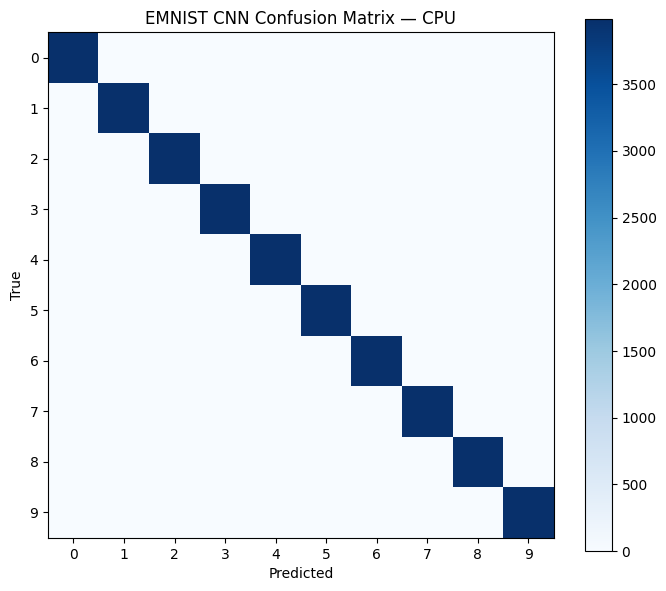

In [15]:

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
)

fig, ax = plt.subplots(
    figsize=(7, 6),
)

image = ax.imshow(
    cm,
    cmap="Blues",
)

ax.set_title(
    f"EMNIST CNN Confusion Matrix — {DEVICE.upper()}"
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "True"
)

ax.set_xticks(
    range(NUM_CLASSES)
)

ax.set_yticks(
    range(NUM_CLASSES)
)

fig.colorbar(
    image,
    ax=ax,
)

fig.tight_layout()
plt.show()


## 16. Training curves

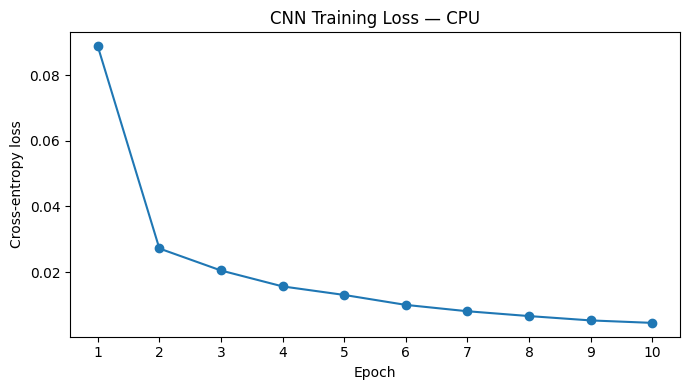

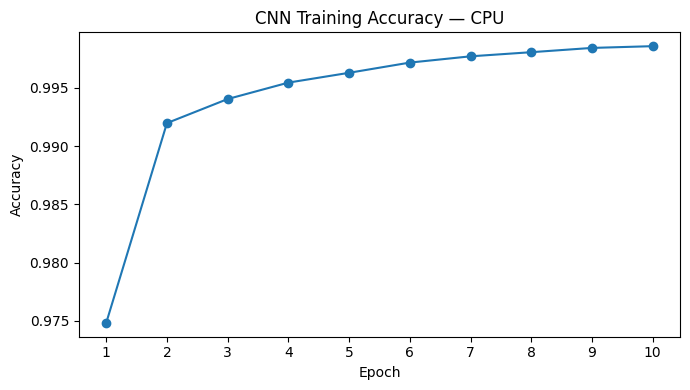

In [16]:

epochs_axis = np.arange(
    1,
    EPOCHS + 1,
)

fig, ax = plt.subplots(
    figsize=(7, 4),
)

ax.plot(
    epochs_axis,
    epoch_losses,
    marker="o",
)

ax.set_title(
    f"CNN Training Loss — {DEVICE.upper()}"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Cross-entropy loss"
)

ax.set_xticks(
    epochs_axis
)

fig.tight_layout()
plt.show()


fig, ax = plt.subplots(
    figsize=(7, 4),
)

ax.plot(
    epochs_axis,
    epoch_accuracies,
    marker="o",
)

ax.set_title(
    f"CNN Training Accuracy — {DEVICE.upper()}"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_xticks(
    epochs_axis
)

fig.tight_layout()
plt.show()


## 17. Final result table

In [17]:

result = {
    "task":
        "Classification",

    "dataset":
        "EMNIST Digits",

    "algorithm":
        "CNN",

    "library":
        "PyTorch",

    "device":
        DEVICE,

    "seed":
        SEED,

    "full_train_examples":
        len(train_dataset),

    "full_test_examples":
        len(test_dataset),

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "trainable_parameters":
        parameter_count,

    "accuracy":
        accuracy,

    "balanced_accuracy":
        balanced_accuracy,

    "macro_precision":
        macro_precision,

    "macro_recall":
        macro_recall,

    "macro_f1":
        macro_f1,

    "weighted_f1":
        weighted_f1,

    "mcc":
        mcc,

    "log_loss":
        test_log_loss,

    "training_time_s":
        training_time_s,

    "mean_epoch_time_s":
        float(
            np.mean(epoch_times)
        ),

    "training_throughput_examples_s":
        training_throughput_examples_s,

    "inference_time_s":
        inference_time_s,

    "inference_throughput_examples_s":
        inference_throughput_examples_s,

    "latency_ms_per_example":
        latency_ms_per_example,

    "peak_process_ram_mb":
        peak_process_ram_mb,

    "peak_gpu_mb":
        peak_gpu_mb,

    "training_energy_kwh":
        training_environmental[
            "energy_kwh"
        ],

    "training_co2_kg":
        training_environmental[
            "co2_kg"
        ],

    "training_co2_g":
        (
            training_environmental[
                "co2_kg"
            ]
            * 1000
            if pd.notna(
                training_environmental[
                    "co2_kg"
                ]
            )
            else np.nan
        ),

    "training_cpu_energy_kwh":
        training_environmental[
            "cpu_energy_kwh"
        ],

    "training_gpu_energy_kwh":
        training_environmental[
            "gpu_energy_kwh"
        ],

    "training_ram_energy_kwh":
        training_environmental[
            "ram_energy_kwh"
        ],

    "inference_energy_kwh":
        inference_environmental[
            "energy_kwh"
        ],

    "inference_co2_kg":
        inference_environmental[
            "co2_kg"
        ],

    "carbon_country":
        training_environmental[
            "country"
        ],
}

result_df = pd.DataFrame(
    [result]
)

display(
    result_df.round(6)
)


,task,dataset,algorithm,library,device,seed,full_train_examples,full_test_examples,batch_size,epochs,learning_rate,trainable_parameters,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,log_loss,training_time_s,mean_epoch_time_s,training_throughput_examples_s,inference_time_s,inference_throughput_examples_s,latency_ms_per_example,peak_process_ram_mb,peak_gpu_mb,training_energy_kwh,training_co2_kg,training_co2_g,training_cpu_energy_kwh,training_gpu_energy_kwh,training_ram_energy_kwh,inference_energy_kwh,inference_co2_kg,carbon_country
0,Classification,EMNIST Digits,CNN,PyTorch,cpu,42,240000,40000,128,10,0.001,421642,0.995575,0.995575,0.995578,0.995575,0.995575,0.995575,0.995084,0.019013,1577.563102,157.755969,1521.333757,13.344384,2997.515634,0.33361,873.859375,NaN,0.007877,0.001093,1.092866,0.003502,0.0,0.004375,0.000067,0.000009,United States


## 18. Save this device result

In [18]:

output_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path(".")
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

result_path = (
    output_dir
    / f"cnn_emnist_{DEVICE}_result.csv"
)

result_df.to_csv(
    result_path,
    index=False,
)

print("Saved:", result_path)


Saved: /kaggle/working/cnn_emnist_cpu_result.csv


## 19. Optional CPU-vs-GPU comparison

In [19]:

cpu_path = (
    output_dir
    / "cnn_emnist_cpu_result.csv"
)

gpu_path = (
    output_dir
    / "cnn_emnist_cuda_result.csv"
)

if cpu_path.exists() and gpu_path.exists():

    cpu = pd.read_csv(
        cpu_path
    ).iloc[0]

    gpu = pd.read_csv(
        gpu_path
    ).iloc[0]

    training_speedup = (
        cpu["training_time_s"]
        / gpu["training_time_s"]
    )

    inference_speedup = (
        cpu["inference_time_s"]
        / gpu["inference_time_s"]
    )

    energy_saving_pct = (
        (
            cpu["training_energy_kwh"]
            - gpu["training_energy_kwh"]
        )
        / cpu["training_energy_kwh"]
        * 100
        if cpu["training_energy_kwh"] > 0
        else np.nan
    )

    carbon_saving_pct = (
        (
            cpu["training_co2_kg"]
            - gpu["training_co2_kg"]
        )
        / cpu["training_co2_kg"]
        * 100
        if cpu["training_co2_kg"] > 0
        else np.nan
    )

    comparison = pd.DataFrame([
        {
            "metric": "Training time (s)",
            "CPU": cpu["training_time_s"],
            "GPU": gpu["training_time_s"],
        },
        {
            "metric": "Inference time (s)",
            "CPU": cpu["inference_time_s"],
            "GPU": gpu["inference_time_s"],
        },
        {
            "metric": "Training energy (kWh)",
            "CPU": cpu["training_energy_kwh"],
            "GPU": gpu["training_energy_kwh"],
        },
        {
            "metric": "Training CO2e (g)",
            "CPU": cpu["training_co2_g"],
            "GPU": gpu["training_co2_g"],
        },
        {
            "metric": "Accuracy",
            "CPU": cpu["accuracy"],
            "GPU": gpu["accuracy"],
        },
        {
            "metric": "Macro F1",
            "CPU": cpu["macro_f1"],
            "GPU": gpu["macro_f1"],
        },
    ])

    display(
        comparison.round(6)
    )

    print(
        f"GPU training speedup = "
        f"{training_speedup:.3f}x"
    )

    print(
        f"GPU inference speedup = "
        f"{inference_speedup:.3f}x"
    )

    print(
        f"GPU training energy saving = "
        f"{energy_saving_pct:.2f}%"
    )

    print(
        f"GPU training carbon saving = "
        f"{carbon_saving_pct:.2f}%"
    )

else:
    print(
        "Run once with DEVICE='cpu' and once with DEVICE='cuda'."
    )


Run once with DEVICE='cpu' and once with DEVICE='cuda'.



# Run procedure

CPU:

```python
DEVICE = "cpu"
```

GPU:

```python
DEVICE = "cuda"
```

The notebook uses the **complete EMNIST Digits train and test splits**.  
There is **no sampling/subsampling**.

CPU/GPU comparison changes only the execution device while holding the experimental setup fixed.
